In [30]:
using Distributions
using Plots
using Turing

┌ Info: Precompiling Turing [fce5fe82-541a-59a6-adf8-730c64b5f9a0]
└ @ Base loading.jl:1278


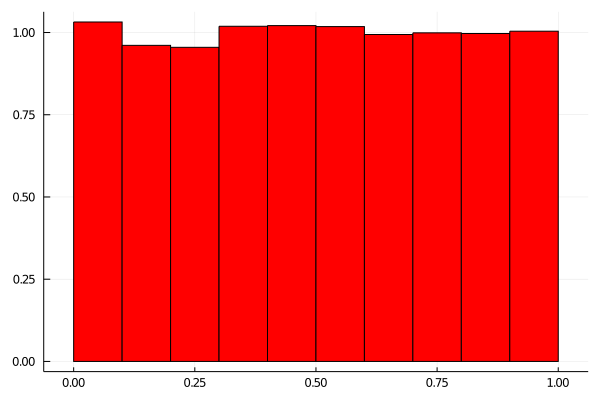

In [2]:
n = 10000
p_priorvals = rand(Uniform(0, 1), n)

plot(p_priorvals, 
     seriestype=:histogram, 
     normalize=true, 
     bins=10, 
     legend=false, 
     color="red")

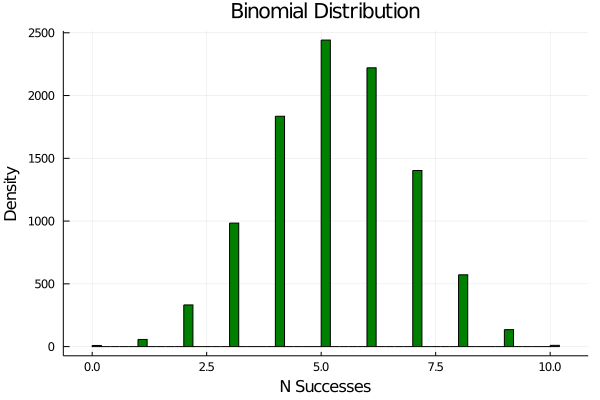

In [28]:
N = 10
p = 0.52
plot(rand(Binomial(N, p), n), 
     seriestype=:histogram,
     label=false, 
     xlabel="N Successes", 
     ylabel="Density", 
     title="Binomial Distribution", 
     color="green")

In [21]:
rand(Binomial(20, 0.5), 3)

3-element Array{Int64,1}:
 12
  6
  7

In [31]:
@model coinflip(y) = begin
    # Prior heads prob (no info) 
    p ~ Uniform(0, 1)
    N = length(y) # observations
    for n in 1:N
        y[n] ~ Bernoulli(p)
    end
end

coinflip (generic function with 1 method)

In [32]:
outcome = [0, 1, 1, 0, 1, 0, 0, 1, 1, 1]

10-element Array{Int64,1}:
 0
 1
 1
 0
 1
 0
 0
 1
 1
 1

In [33]:
iterations = 1000
eps = 0.05 # ?
tau = 10   # ?
chain = sample(coinflip(outcome[1]), HMC(eps, tau), iterations)

Chains MCMC chain (1000×10×1 Array{Float64,3}):

Iterations        = 1:1000
Thinning interval = 1
Chains            = 1
Samples per chain = 1000
parameters        = p
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size

Summary Statistics
  parameters      mean       std   naive_se      mcse       ess      rhat 
      Symbol   Float64   Float64    Float64   Float64   Float64   Float64 

           p    0.3626    0.2575     0.0081    0.0480   22.7760    1.0171

Quantiles
  parameters      2.5%     25.0%     50.0%     75.0%     97.5% 
      Symbol   Float64   Float64   Float64   Float64   Float64 

           p    0.0029    0.1396    0.3177    0.5626    0.8897


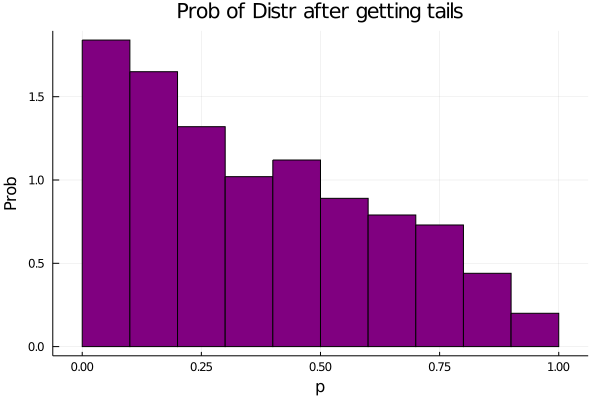

In [36]:
psummary = chain[:p]
plot(psummary, 
     seriestype=:histogram, 
     normed=true, 
     legend=false, 
     color="purple",
     xlabel="p",
     ylabel="Prob",
     title="Prob of Distr after getting tails")

In [37]:
samples = []
for i in 2:10
    global chain_
    chain_ = sample(coinflip(outcome[1:i]), HMC(eps, tau), iterations)
    push!(samples, chain_)
end

Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00


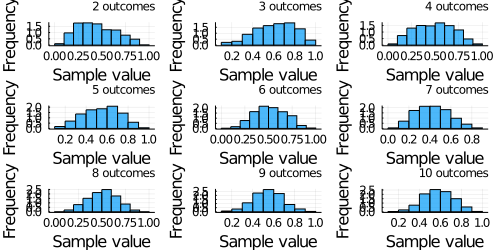

In [39]:
plots = histogram.(samples, normalized=true, legend=false, bins=10)
p_ = plot(plots..., 
          layout=9, 
          title=["$i outcomes" for j in 1:1, i in 2:10], 
          titleloc=:right, 
          titlefont=font(8))